# HW1  Try out gradient descent


You should submit this jupyter notebook with your solutions. The solutions should include the code and also the output of all the cells.

Note that for the problmes that require a cost function as input you should always use the most recent cost function that you have implemented (unless specified otherwise).

**1) [5 points]** Calculate the derivative of following cost function and write it down:

$g(w) = \frac{1}{50}\left(w^6+ 3w^4 - 15w^3 + w^2 + 10w - 50 \right)$

$\frac{\partial}{\partial w}g(w) = \frac{1}{50}\left(6w^5 + 12w^3 - 45w^2 + 2w + 10\right)$

**2) [25 points]** Implement the gradient descent function as discussed in class using the gradient derived in the last problem. The function should return the cost history for each step. Use the code template below:


In [14]:
#gradient descent function
#inputs: alpha (learning rate parameter), max_its (maximum number of iterations), w0 (initialization)
import numpy as np
import matplotlib.pyplot as plt

# Problem 2: Gradient descent function for the specific cost function
def gradient_descent(alpha, max_its, w0):
    # Cost function g(w)
    def g(w):
        return (1/50) * (w**6 + 3*w**4 - 15*w**3 + w**2 + 10*w - 50)
    
    # Derivative of g(w) from problem 1
    def g_derivative(w):
        return (1/50) * (6*w**5 + 12*w**3 - 45*w**2 + 2*w + 10)
    
    # Initialize
    w = w0
    cost_history = []
    
    # Gradient descent iterations
    for i in range(max_its):
        # Record current cost
        cost_history.append(g(w))
        
        # Update w
        w = w - alpha * g_derivative(w)
    
    return cost_history

**3) [10 points]** Run the gradient_descent function you implemented three times, with the following parameters. Generate a single plot showing the cost as a function of step number for all three runs (combine all three runs into a single plot). If you are not familiar with plotting in python, here is the docs for matplotlib:(https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot).


$w^0$ = 2.0
max_its = 2000

# first run
alpha = 0.01
# second run
alpha = 0.001
# third run
alpha = 0.0001


<Figure size 1200x800 with 0 Axes>

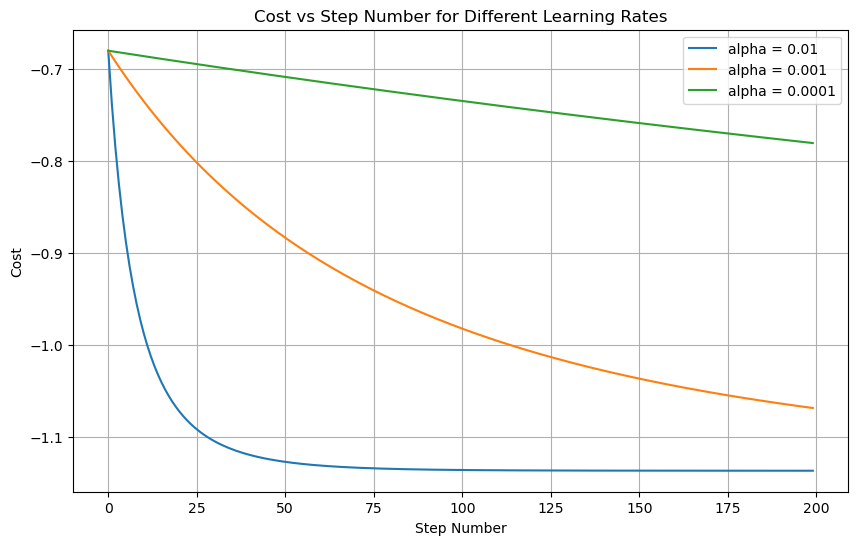

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

# Parameters
w0 = 2.0
max_its = 2000

# Three different learning rates
alphas = [0.01, 0.001, 0.0001]
labels = ['alpha = 0.01', 'alpha = 0.001', 'alpha = 0.0001']

# Run gradient descent and plot
plt.figure(figsize=(10, 6))

for alpha, label in zip(alphas, labels):
    cost_history = gradient_descent(alpha, max_its, w0)
    plt.plot(cost_history[:200], label=label)

plt.xlabel('Step Number')
plt.ylabel('Cost')
plt.title('Cost vs Step Number for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

**For the next few problems we will be comparing fixed and diminishing learning rates**

Take the following cost function:
\begin{equation}
g(w) = \left \vert w \right \vert
\end{equation}

**4) [5 points]** Is this function convex? If no, why not? If yes, where is its global minimum?

In [16]:
"""
No, the function g(w) = |w| is not convex everywhere because it has a non-differentiable point at w = 0. 
However, it is convex on the intervals w ≥ 0 and w ≤ 0 separately. 
The global minimum is at w = 0.
"""
print("""
No, the function g(w) = |w| is not convex everywhere because it has a non-differentiable point at w = 0.
However, it is convex on the intervals w ≥ 0 and w ≤ 0 separately.
The global minimum is at w = 0.
""")


No, the function g(w) = |w| is not convex everywhere because it has a non-differentiable point at w = 0.
However, it is convex on the intervals w ≥ 0 and w ≤ 0 separately.
The global minimum is at w = 0.



**5) [5 points]** What is the derivative of the cost function?

The derivative is:

$g'(w) = 1$ if $w > 0$  
$g'(w) = -1$ if $w < 0$  
$g'(w)$ is undefined if $w = 0$

Or equivalently: $g'(w) = \text{sign}(w)$ for $w \neq 0$, undefined at $w = 0$.

**6) [20 points]** Rewrite the gradient descent function from question 2 such that it takes the cost funciton g as input and uses the autograd library to calculate the gradient. The function should return the weight and cost history for each step. Use the code template below.

autograd is a python package for automatic calculation of the gradient. Here is a tutorial on it: (http://www.cs.toronto.edu/~rgrosse/courses/csc321_2017/tutorials/tut4.pdf

Note that in Python you can pass functions around like any other variables. That is why you can pass the cost function g to the gradient_descent function.

You should be able to install it by running "pip install autograd" in a cell in your Jupyter notebook.

In [17]:
from autograd import grad

#gradient descent function
#inputs: g (cost function), alpha (learning rate parameter), max_its (maximum number of iterations), w (initialization)
def gradient_descent(g,alpha,max_its,w0):
    gradient = grad(g)   ## This is how you use the autograd library to find the gradient of a function
    # Initialize
    w = w0
    weight_history = [w]
    cost_history = [g(w)]
    
    # Gradient descent iterations
    for i in range(max_its):
        # Compute gradient
        grad_w = gradient(w)
        
        # Update w
        w = w - alpha * grad_w
        
        # Record history
        weight_history.append(w)
        cost_history.append(g(w))
    return weight_history,cost_history

**7) [10 points]** Make a run of max_its=20 steps of gradient descent with initialization at the point $w^0 = 1.75$, and a fixed learning rate of $\alpha = 0.5$. Using the cost and weight history, plot the cost as a function of the weight for each step (cost on y-axis, weight on x-axis). Recall that the terms weight and parameter used interchangeably and both refer to w.

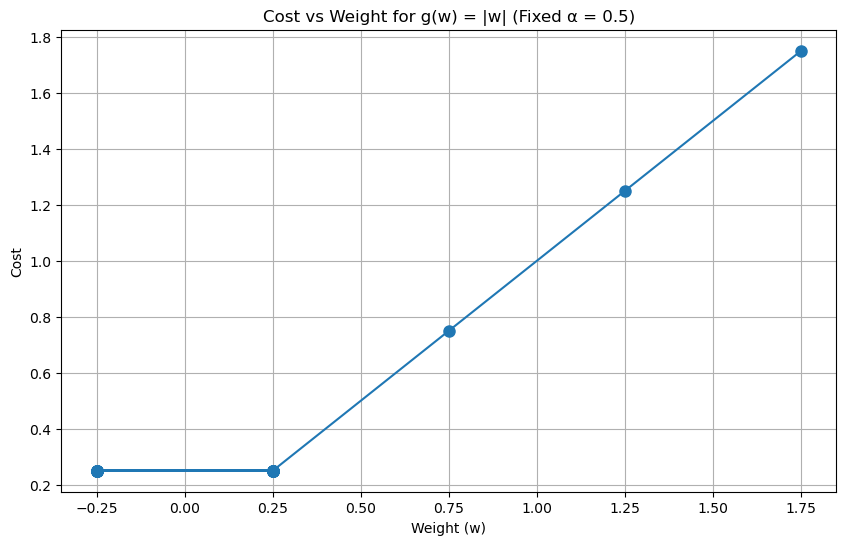

Initial weight: 1.75, Final weight: -0.250000
Initial cost: 1.75, Final cost: 0.250000


In [18]:
def g_abs(w):
    return abs(w)

# Run gradient descent with parameters from question 7
w0 = 1.75
alpha = 0.5
max_its = 20

# Use the gradient_descent function from question 6
weight_history, cost_history = gradient_descent(g_abs, alpha, max_its, w0)

# Plot cost as function of weight
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 6))
plt.plot(weight_history, cost_history, 'o-', markersize=8)
plt.xlabel('Weight (w)')
plt.ylabel('Cost')
plt.title('Cost vs Weight for g(w) = |w| (Fixed α = 0.5)')
plt.grid(True)
plt.show()

print(f"Initial weight: {weight_history[0]}, Final weight: {weight_history[-1]:.6f}")
print(f"Initial cost: {cost_history[0]}, Final cost: {cost_history[-1]:.6f}")

**8) [15 points]** Make a run of max_its=20 steps of gradient descent with initialization at the point $w^0 = 1.75$, using the diminishing rule $\alpha = \frac{1}{k}$ (for this you have to modify the gradient_descent function slightly. Use the code template below. Using the cost and wieght history, plot the cost as a function of the weight for each step (cost on y-axis, weight on x-axis)

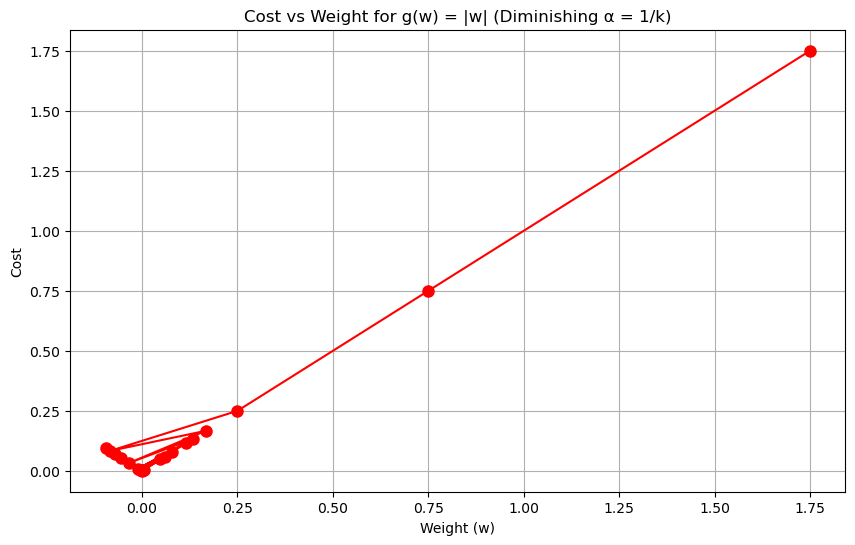

Initial weight: 1.75, Final weight: 0.04767501590257009
Initial cost: 1.75, Final cost: 0.04767501590257009


In [19]:
def gradient_descent_diminishing(g, alpha, max_its, w0):
    gradient = grad(g)
    
    # Initialize
    w = w0
    weight_history = [w]
    cost_history = [g(w)]
    
    # Gradient descent iterations
    for k in range(1, max_its + 1):
        # Compute learning rate
        if alpha == 'diminishing':
            current_alpha = 1/k
        else:
            current_alpha = alpha
        
        # Compute gradient
        grad_w = gradient(w)
        
        # Update w
        w = w - current_alpha * grad_w
        
        # Record history
        weight_history.append(w)
        cost_history.append(g(w))
    
    return weight_history, cost_history


# Run with diminishing learning rate
w0 = 1.75
max_its = 20

weight_history_dim, cost_history_dim = gradient_descent_diminishing(g_abs, 'diminishing', max_its, w0)

# Plot cost as function of weight
plt.figure(figsize=(10, 6))
plt.plot(weight_history_dim, cost_history_dim, 'o-', markersize=8, color='red')
plt.xlabel('Weight (w)')
plt.ylabel('Cost')
plt.title('Cost vs Weight for g(w) = |w| (Diminishing α = 1/k)')
plt.grid(True)
plt.show()

print(f"Initial weight: {weight_history_dim[0]}, Final weight: {weight_history_dim[-1]}")
print(f"Initial cost: {cost_history_dim[0]}, Final cost: {cost_history_dim[-1]}")

**9) [10 points]**  Generate a single plot showing the cost as a function of step number for both runs (combine all  runs into a single plot). Which approach would be better? Write your justification?

**We will now look at the oscilating behavior of gradient descent.**

Take the following cost function:
$g(w) = w_0^2 + w_1^2 + 2\sin(1.5 (w_0 + w_1)) +2$

Note that this cost function has two parameters.

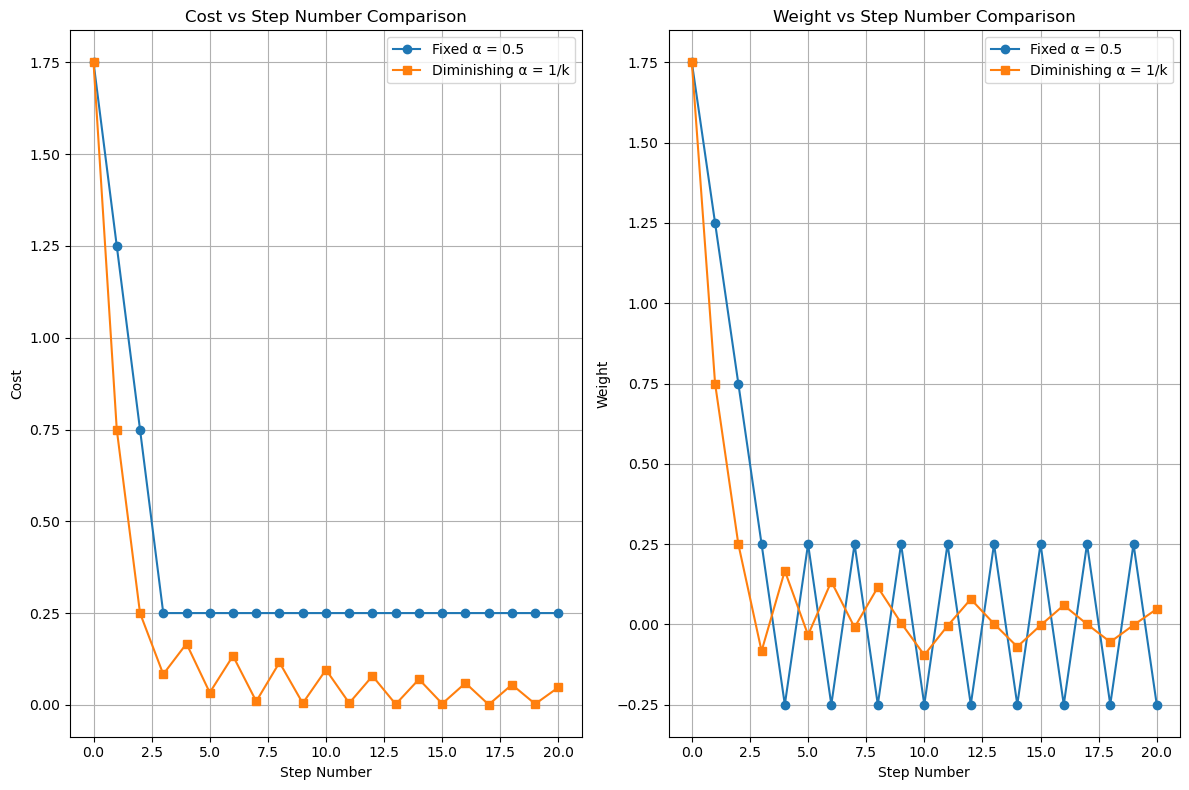

Fixed α = 0.5:
  Final weight: -0.250000, Final cost: 0.250000
  Cost reduction: 85.71%

Diminishing α = 1/k:
  Final weight: 0.047675, Final cost: 0.047675
  Cost reduction: 97.28%


In [20]:
# Question 9: Compare fixed vs diminishing learning rates

# First, make sure all functions are defined
from autograd import grad
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Fixed learning rate version (from question 6)
def gradient_descent_fixed(g, alpha, max_its, w0):
    gradient = grad(g)
    
    w = w0
    weight_history = [w]
    cost_history = [g(w)]
    
    for i in range(max_its):
        grad_w = gradient(w)
        w = w - alpha * grad_w
        weight_history.append(w)
        cost_history.append(g(w))
    
    return weight_history, cost_history

# 2. Diminishing learning rate version (from question 8)
def gradient_descent_diminishing(g, alpha, max_its, w0):
    gradient = grad(g)
    
    w = w0
    weight_history = [w]
    cost_history = [g(w)]
    
    for k in range(1, max_its + 1):
        # Compute learning rate
        if alpha == 'diminishing':
            current_alpha = 1/k
        else:
            current_alpha = alpha
        
        grad_w = gradient(w)
        w = w - current_alpha * grad_w
        weight_history.append(w)
        cost_history.append(g(w))
    
    return weight_history, cost_history

# Define the absolute value cost function
def g_abs(w):
    return abs(w)

# Compare both approaches
plt.figure(figsize=(12, 8))

# Fixed learning rate (from problem 7)
w0 = 1.75
alpha_fixed = 0.5
max_its = 20

weight_history_fixed, cost_history_fixed = gradient_descent_fixed(g_abs, alpha_fixed, max_its, w0)

# Diminishing learning rate (from problem 8)
weight_history_dim, cost_history_dim = gradient_descent_diminishing(g_abs, 'diminishing', max_its, w0)

# Plot cost vs step number
plt.subplot(1, 2, 1)
plt.plot(cost_history_fixed, 'o-', label='Fixed α = 0.5')
plt.plot(cost_history_dim, 's-', label='Diminishing α = 1/k')
plt.xlabel('Step Number')
plt.ylabel('Cost')
plt.title('Cost vs Step Number Comparison')
plt.legend()
plt.grid(True)

# Plot weight vs step number
plt.subplot(1, 2, 2)
plt.plot(weight_history_fixed, 'o-', label='Fixed α = 0.5')
plt.plot(weight_history_dim, 's-', label='Diminishing α = 1/k')
plt.xlabel('Step Number')
plt.ylabel('Weight')
plt.title('Weight vs Step Number Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final values comparison
print("Fixed α = 0.5:")
print(f"  Final weight: {weight_history_fixed[-1]:.6f}, Final cost: {cost_history_fixed[-1]:.6f}")
print(f"  Cost reduction: {100*(cost_history_fixed[0]-cost_history_fixed[-1])/cost_history_fixed[0]:.2f}%")

print("\nDiminishing α = 1/k:")
print(f"  Final weight: {weight_history_dim[-1]:.6f}, Final cost: {cost_history_dim[-1]:.6f}")
print(f"  Cost reduction: {100*(cost_history_dim[0]-cost_history_dim[-1])/cost_history_dim[0]:.2f}%")

**10) [5 points]** Make sure your gradient descent function from problem 6 can handle cost functions with more than one parameter. You may need to rewrite it if you were not careful. Use the code template below (if your function from problem 6 is good, you can just copy and paste it here)

In [21]:
from autograd import grad

# Gradient descent function for multi-parameter functions
def gradient_descent_multi(g, alpha, max_its, w0):
    gradient = grad(g)
    
    # Initialize
    w = np.array(w0, dtype=float)
    weight_history = [w.copy()]
    cost_history = [g(w)]
    
    # Gradient descent iterations
    for i in range(max_its):
        # Compute gradient
        grad_w = gradient(w)
        
        # Update w
        w = w - alpha * grad_w
        
        # Record history
        weight_history.append(w.copy())
        cost_history.append(g(w))
    
    return weight_history, cost_history

**11) [10 points]** Run the gradient_descent function with the cost function above three times with the following parameters. Generate a single plot showing the cost as a function of step number for all three runs (combine all three runs into a single plot). Use the code template below. Which alpha leads to an oscillating behavior?

$w^0$ = [3.0,3.0]
max_its = 10

# first run
alpha = 0.01
# second run
alpha = 0.1
# third run
alpha = 1



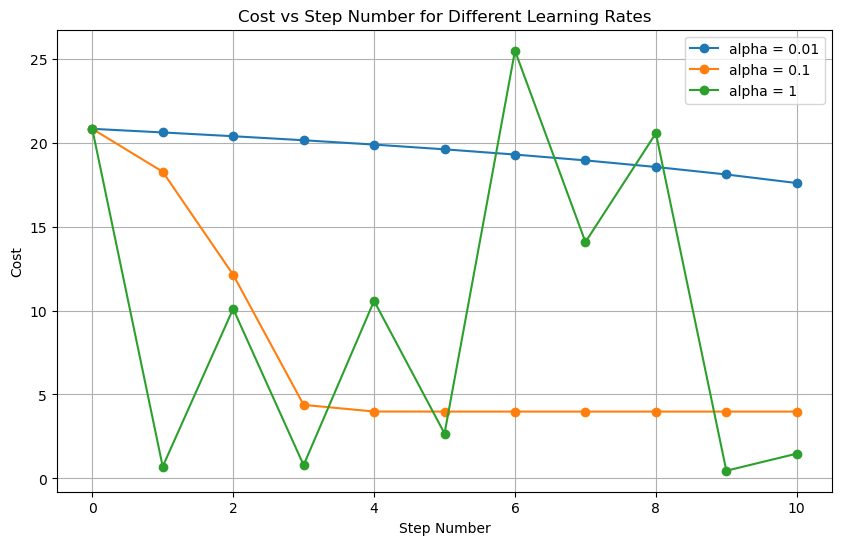

Oscillation analysis:
alpha = 0.01: 0 oscillation points detected
alpha = 0.1: 0 oscillation points detected
alpha = 1: 9 oscillation points detected


In [22]:
import autograd.numpy as np

# Define the cost function with two parameters
def g_two_param(w):
    w0, w1 = w[0], w[1]
    return w0**2 + w1**2 + 2*np.sin(1.5*(w0 + w1)) + 2

# Parameters
w0 = [3.0, 3.0]
max_its = 10
alphas = [0.01, 0.1, 1]
labels = ['alpha = 0.01', 'alpha = 0.1', 'alpha = 1']

# Run and plot
plt.figure(figsize=(10, 6))

for alpha, label in zip(alphas, labels):
    weight_history, cost_history = gradient_descent_multi(g_two_param, alpha, max_its, w0)
    plt.plot(cost_history, 'o-', label=label, markersize=6)

plt.xlabel('Step Number')
plt.ylabel('Cost')
plt.title('Cost vs Step Number for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

# Check for oscillating behavior
print("Oscillation analysis:")
for alpha, label in zip(alphas, labels):
    weight_history, cost_history = gradient_descent_multi(g_two_param, alpha, max_its, w0)
    # Check if cost increases and decreases alternately
    oscillations = sum([1 for i in range(1, len(cost_history)-1) 
                       if (cost_history[i] > cost_history[i-1] and cost_history[i] > cost_history[i+1]) 
                       or (cost_history[i] < cost_history[i-1] and cost_history[i] < cost_history[i+1])])
    print(f"{label}: {oscillations} oscillation points detected")

**12) [15 points]** This problem is about learning to tune fixed step length for gradient descent. Here, you are given a cost function:
$g(w) = 2w_0^2 + w_1^2 +4w_2^2$

Assume your $w^0$= [5,5,5] and your max_iter = 100

Use your latest gradient descent function with a fixed learning rate. Play around with at least 5 different values of alpha (***using your intuition; Hint: you should try with alpha values smaller than 0.1***). Generate a single plot of the cost as a function of the number of iterations. Which value of alpha seems to converge the fastest?

Not that your grade will not depend on how well you do, as long as you try at least 5 different values for alpha and plot them.

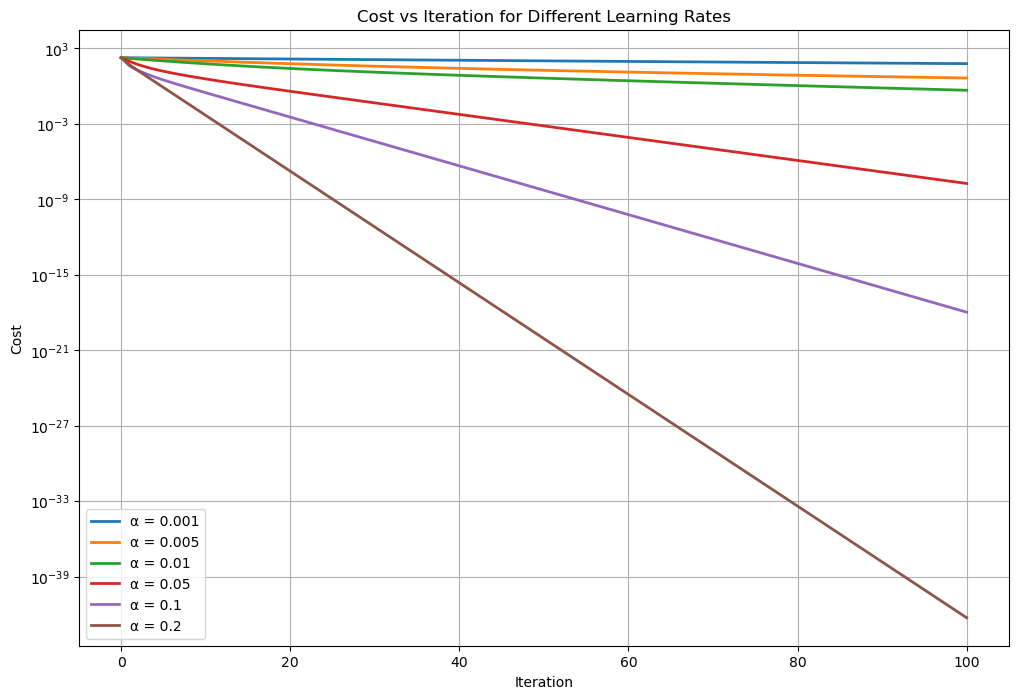

Convergence analysis (final cost after 100 iterations):
α = 0.0010: Final cost = 5.924189e+01
α = 0.0050: Final cost = 4.257350e+00
α = 0.0100: Final cost = 4.539348e-01
α = 0.0500: Final cost = 1.763770e-08
α = 0.1000: Final cost = 1.037379e-18
α = 0.2000: Final cost = 5.335315e-43

Best alpha: 0.2 with final cost: 5.335315e-43


In [23]:
# Define the quadratic cost function
def g_quadratic(w):
    return 2*w[0]**2 + w[1]**2 + 4*w[2]**2

# Parameters
w0 = [5.0, 5.0, 5.0]
max_its = 100

# Try different alpha values
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
labels = [f'α = {a}' for a in alphas]

# Run and plot
plt.figure(figsize=(12, 8))

for alpha, label in zip(alphas, labels):
    weight_history, cost_history = gradient_descent_multi(g_quadratic, alpha, max_its, w0)
    plt.plot(cost_history, label=label, linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.yscale('log')  # Use log scale to better see differences
plt.show()

# Find which alpha converges fastest
print("Convergence analysis (final cost after 100 iterations):")
best_alpha = None
best_cost = float('inf')

for alpha in alphas:
    weight_history, cost_history = gradient_descent_multi(g_quadratic, alpha, max_its, w0)
    final_cost = cost_history[-1]
    print(f"α = {alpha:.4f}: Final cost = {final_cost:.6e}")
    
    if final_cost < best_cost:
        best_cost = final_cost
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha} with final cost: {best_cost:.6e}")